### 1. Imports

In [18]:
# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

### 2. Configuración

In [19]:
# =========================================================
# CONFIGURATION
# =========================================================

pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

### 3. Carga dataset

In [20]:
# =========================================================
# LOAD FEATURED DATASET
# =========================================================

path = "../data/gold/featured_dataset_v1.parquet"

df = pd.read_parquet(path)

print(df.shape)

df.head()

(140256, 61)


,Temperatura,Temperatura màxima,Temperatura mínima,Humitat relativa,Humitat relativa màxima,Humitat relativa mínima,Pressió atmosfèrica,Pressió atmosfèrica mínima,Velocitat del vent a 6 m (esc.),Ratxa màxima del vent a 6 m,Precipitació,Precipitació màxima en 1 minut,Irradiància solar global,wind_u,wind_v,sst,sst_original,wave_height,wave_height_h13,wave_period_mean,wave_period_tm02,wave_peak_period,wave_max_period,wave_direction,wave_peak_direction,wave_angular_spread,sst_roll_6h,sst_roll_24h,sst_delta_3h,sst_delta_24h,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,month,hour,is_operational_hour,wind_data_available,valid_wind_observation,operational_gap,day_of_year,season,hour_sin,hour_cos,doy_sin,doy_cos,pressure_tendency_3h,pressure_tendency_6h,air_temp_combined,coastal_inland_temp_diff,land_sea_temp_gradient,thermal_wind_flag,thermal_event,sailable_wind,daily_temp_range,solar_roll_3h,solar_roll_6h,sst_climatology,sst_anomaly,solar_gradient_interaction
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2010-01-01 00:00:00,11.80,12.1,11.3,48.0,49.0,46.0,989.5,989.0,7.40,16.900000,0.2,0.2,0.0,-1.852812,-7.164292,14.0,14.0,2.05,1.84,5.55,5.14,6.65,6.78,210.0,210.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,0,0,1,1,0.000000,1.000000,0.017213,0.999852,NaN,NaN,11.80,NaN,-2.20,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 01:00:00,10.90,11.3,10.3,49.0,51.0,47.0,990.0,989.0,7.80,17.200001,0.0,0.0,0.0,-0.611981,-7.775955,14.0,14.0,1.88,1.78,5.53,5.06,7.13,7.00,213.0,205.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,0,0,1,1,0.258819,0.965926,0.017213,0.999852,NaN,NaN,10.90,NaN,-3.10,False,0,0,3.725001,NaN,NaN,NaN,NaN,-0.0
2010-01-01 02:00:00,10.30,10.3,10.2,49.5,51.0,48.0,990.0,989.0,7.95,15.900000,0.0,0.0,0.0,-0.208105,-7.947276,14.0,14.0,1.95,1.84,5.76,5.02,7.13,7.67,217.0,219.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,2,0,0,0,0,1,1,0.500000,0.866025,0.017213,0.999852,NaN,NaN,10.30,NaN,-3.70,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0
2010-01-01 03:00:00,9.85,10.2,9.6,47.0,48.0,47.0,990.5,990.0,8.00,16.299999,0.0,0.0,0.0,-0.627673,-7.975338,14.0,14.0,2.24,2.08,6.10,5.53,7.68,8.55,214.0,213.0,24.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,3,0,0,0,0,1,1,0.707107,0.707107,0.017213,0.999852,1.0,NaN,9.85,NaN,-4.15,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0
2010-01-01 04:00:00,9.50,9.6,9.4,46.0,47.0,45.0,991.0,990.0,7.15,15.900000,0.0,0.0,0.0,-1.241584,-7.041375,14.0,14.0,2.62,2.37,6.46,5.85,7.67,8.19,214.0,212.0,23.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1,4,0,0,0,0,1,1,0.866025,0.500000,0.017213,0.999852,1.0,NaN,9.50,NaN,-4.50,False,0,0,3.725001,0.0,NaN,NaN,NaN,-0.0


### 4. Exploración inicial

In [21]:
# =========================================================
# DATASET OVERVIEW
# =========================================================

print(df.shape)

print()

print(df.index.min())
print(df.index.max())

print()

df.info()

(140256, 61)

2010-01-01 00:00:00
2025-12-31 23:00:00

<class 'pandas.DataFrame'>
DatetimeIndex: 140256 entries, 2010-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 61 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Temperatura                      140063 non-null  float32
 1   Temperatura màxima               140072 non-null  float32
 2   Temperatura mínima               140073 non-null  float32
 3   Humitat relativa                 140099 non-null  float32
 4   Humitat relativa màxima          140103 non-null  float32
 5   Humitat relativa mínima          140099 non-null  float32
 6   Pressió atmosfèrica              140113 non-null  float32
 7   Pressió atmosfèrica mínima       140113 non-null  float32
 8   Velocitat del vent a 6 m (esc.)  140148 non-null  float32
 9   Ratxa màxima del vent a 6 m      140148 non-null  float32
 10  Precipitació                     140256 non-null  

In [22]:
# =========================================================
# TARGET ANALYSIS
# =========================================================

TARGET = "thermal_wind_flag"

print(df[TARGET].value_counts())

print()

print(
    df[TARGET]
    .value_counts(normalize=True)
    * 100
)

thermal_wind_flag
False    135567
True       4689
Name: count, dtype: int64

thermal_wind_flag
False    96.656828
True      3.343172
Name: proportion, dtype: float64


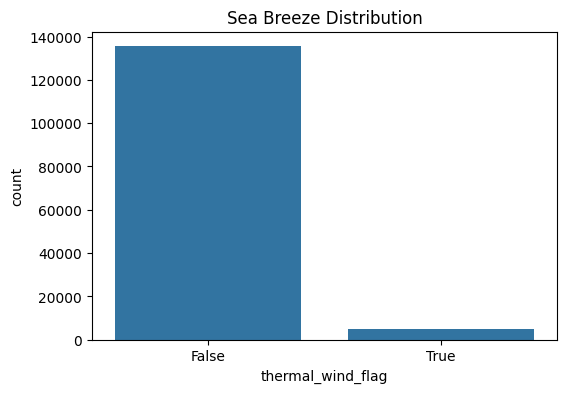

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df[TARGET]
)

plt.title("Sea Breeze Distribution")

plt.show()

In [25]:
daily_target = (
    df["thermal_wind_flag"]
    .resample("D")
    .max()
    .astype(int)
)

In [26]:
daily_target.value_counts()

thermal_wind_flag
0    4555
1    1289
Name: count, dtype: int64

In [27]:
daily_target.value_counts(normalize=True) * 100

thermal_wind_flag
0    77.94319
1    22.05681
Name: proportion, dtype: float64

In [28]:
daily_thermal_hours = (
    df["thermal_wind_flag"]
    .resample("D")
    .sum()
)

In [29]:
daily_target = (
    df["thermal_wind_flag"]
    .resample("D")
    .max()
    .astype(int)
)

print(daily_target.value_counts())

print()

print(
    daily_target.value_counts(normalize=True) * 100
)

thermal_wind_flag
0    4555
1    1289
Name: count, dtype: int64

thermal_wind_flag
0    77.94319
1    22.05681
Name: proportion, dtype: float64


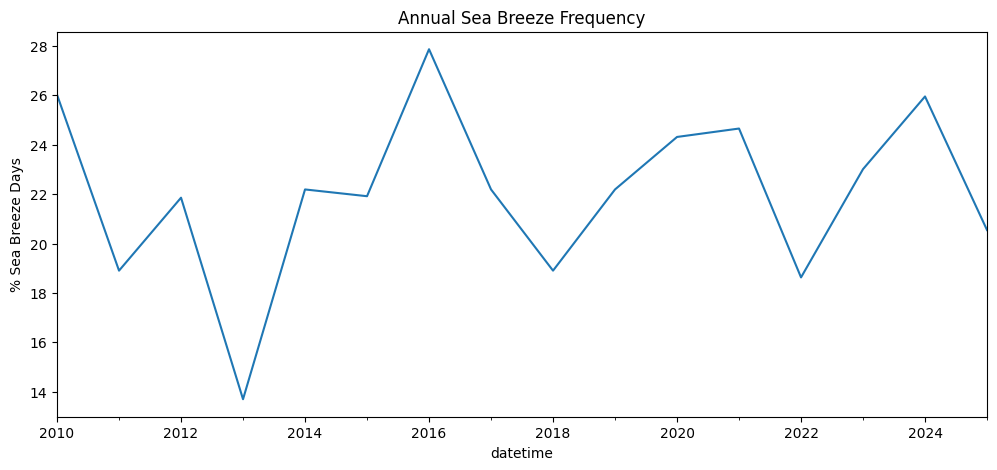

In [31]:
daily_target = (
    df["thermal_wind_flag"]
    .resample("D")
    .max()
    .astype(int)
)

annual_counts = (
    daily_target
    .resample("YE")
    .mean()
    * 100
)

annual_counts.plot(
    figsize=(12,5)
)

plt.ylabel("% Sea Breeze Days")
plt.title("Annual Sea Breeze Frequency")

plt.show()